In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
base_path = Path.cwd().parent.parent

Using NIH side data, I want to separate based on size and/or funding growth.

In [11]:
data = pd.read_csv(base_path / "Data/NIH_v4/Working/nih_field_mech_merge.csv")

In [12]:
data.head()

,year,CBSA_code,funding_real,funding,pop,log_funding,funding_pc,log_funding_pc,CBSA_title,field_admin,...,field_engineering,field_medicine,field_pop_behave_science,mech_research,mech_infrastructure,mech_training,mech_contracts,mech_other,total_share_field,total_share_mech
0,1992.0,10180,0.0,0.0,148709.0,0.0,0.0,0.0,"Abilene, TX",0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1993.0,10180,0.0,0.0,150958.0,0.0,0.0,0.0,"Abilene, TX",0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1994.0,10180,0.0,0.0,151213.0,0.0,0.0,0.0,"Abilene, TX",0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1995.0,10180,0.0,0.0,152888.0,0.0,0.0,0.0,"Abilene, TX",0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1996.0,10180,0.0,0.0,152535.0,0.0,0.0,0.0,"Abilene, TX",0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Get funding growth measure:

In [15]:
# make a new dataframe with only the growth measure
nih_growth = data.copy()
nih_growth = nih_growth.loc[(nih_growth['year']==1998) | (nih_growth['year']==2003)]

In [25]:
wide = nih_growth.pivot(index=['CBSA_code', 'CBSA_title'], columns='year', values=['funding', 'log_funding', 'funding_pc', 'log_funding_pc'])

In [33]:
diff = wide.xs(2003, level=1, axis=1) - wide.xs(1998, level=1, axis=1)
diff.columns = [f"diff_{c}" for c in diff.columns]

In [72]:
diff.head()

,,diff_funding,diff_log_funding,diff_funding_pc,diff_log_funding_pc
CBSA_code,CBSA_title,,,,
10180,"Abilene, TX",0.000000e+00,0.000000,0.000000,0.000000
10420,"Akron, OH",8.300828e+05,0.101270,0.971579,0.075901
10500,"Albany, GA",-4.120651e+04,-10.626376,-0.265847,-0.235741
10580,"Albany-Schenectady-Troy, NY",1.953923e+07,0.430273,21.833969,0.393203
10740,"Albuquerque, NM",2.961052e+07,0.655446,33.590622,0.537710


In [73]:
wide.head()

funding               log_funding  \
year                                         1998.0        2003.0      1998.0   
CBSA_code CBSA_title                                                            
10180     Abilene, TX                  0.000000e+00  0.000000e+00    0.000000   
10420     Akron, OH                    7.788686e+06  8.618769e+06   15.868183   
10500     Albany, GA                   4.120651e+04  0.000000e+00   10.626376   
10580     Albany-Schenectady-Troy, NY  3.633992e+07  5.587915e+07   17.408428   
10740     Albuquerque, NM              3.197676e+07  6.158729e+07   17.280520   

                                                 funding_pc             \
year                                      2003.0     1998.0     2003.0   
CBSA_code CBSA_title                                                     
10180     Abilene, TX                   0.000000   0.000000   0.000000   
10420     Akron, OH                    15.969453  11.320946  12.292525   
10500     Albany, GA                    0.000000   0.265847   0.000000   
10580     Albany-Schenectady-Troy, NY  17.838701  44.325035  66.159004   
10740     Albuquerque, NM              17.935966  46.172432  79.763054   

                                      log_funding_pc            
year                                          1998.0    2003.0  
CBSA_code CBSA_title                                            
10180     Abilene, TX                       0.000000  0.000000  
10420     Akron, OH                         2.511301  2.587202  
10500     Albany, GA                        0.235741  0.000000  
10580     Albany-Schenectady-Troy, NY       3.813859  4.207063  
10740     Albuquerque, NM                   3.853810  4.391520

In [90]:
nih_98_03 = wide.copy()
nih_98_03.columns = [f"{var}_{str(int(year))}" for var, year in nih_98_03.columns]
nih_98_03.head()

,,funding_1998,funding_2003,log_funding_1998,log_funding_2003,funding_pc_1998,funding_pc_2003,log_funding_pc_1998,log_funding_pc_2003
CBSA_code,CBSA_title,,,,,,,,
10180,"Abilene, TX",0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
10420,"Akron, OH",7.788686e+06,8.618769e+06,15.868183,15.969453,11.320946,12.292525,2.511301,2.587202
10500,"Albany, GA",4.120651e+04,0.000000e+00,10.626376,0.000000,0.265847,0.000000,0.235741,0.000000
10580,"Albany-Schenectady-Troy, NY",3.633992e+07,5.587915e+07,17.408428,17.838701,44.325035,66.159004,3.813859,4.207063
10740,"Albuquerque, NM",3.197676e+07,6.158729e+07,17.280520,17.935966,46.172432,79.763054,3.853810,4.391520


In [91]:
init_diff = nih_98_03.merge(diff, on=['CBSA_code', 'CBSA_title'], how='inner', indicator=True)

In [92]:
print(init_diff['_merge'].value_counts())
init_diff = init_diff.drop(columns='_merge')
init_diff.head()

_merge
both          357
left_only       0
right_only      0
Name: count, dtype: int64


,,funding_1998,funding_2003,log_funding_1998,log_funding_2003,funding_pc_1998,funding_pc_2003,log_funding_pc_1998,log_funding_pc_2003,diff_funding,diff_log_funding,diff_funding_pc,diff_log_funding_pc
CBSA_code,CBSA_title,,,,,,,,,,,,
10180,"Abilene, TX",0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
10420,"Akron, OH",7.788686e+06,8.618769e+06,15.868183,15.969453,11.320946,12.292525,2.511301,2.587202,8.300828e+05,0.101270,0.971579,0.075901
10500,"Albany, GA",4.120651e+04,0.000000e+00,10.626376,0.000000,0.265847,0.000000,0.235741,0.000000,-4.120651e+04,-10.626376,-0.265847,-0.235741
10580,"Albany-Schenectady-Troy, NY",3.633992e+07,5.587915e+07,17.408428,17.838701,44.325035,66.159004,3.813859,4.207063,1.953923e+07,0.430273,21.833969,0.393203
10740,"Albuquerque, NM",3.197676e+07,6.158729e+07,17.280520,17.935966,46.172432,79.763054,3.853810,4.391520,2.961052e+07,0.655446,33.590622,0.537710


In [93]:
diff_funding_pc = init_diff.sort_values(by=['diff_funding_pc'])
diff_funding = init_diff.sort_values(by=['diff_funding'])

### Make some visuals

<Axes: xlabel='funding_pc_1998', ylabel='diff_funding_pc'>

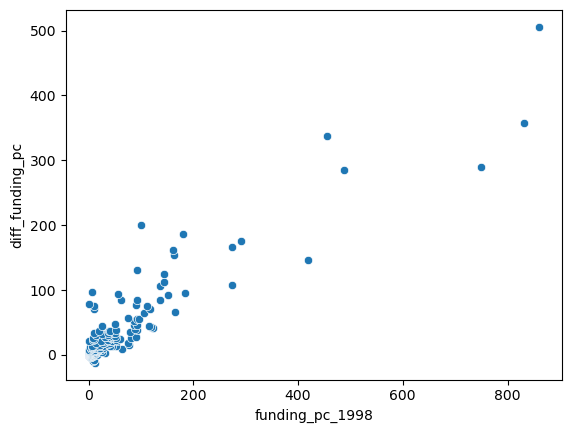

In [94]:
sns.scatterplot(diff_funding_pc, x='funding_pc_1998', y='diff_funding_pc')

<Axes: xlabel='funding', ylabel='diff_funding'>

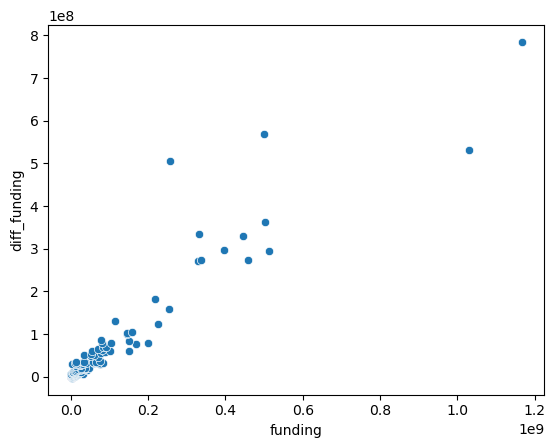

In [59]:
sns.scatterplot(diff_funding, x='funding', y='diff_funding')

Note: With this set of growth rates, I should re-run histograms.

### Split into places with funding

In [131]:
init_diff.to_csv(base_path / "Data/NIH_v4/Working/nih_growth.csv")

KeyError: 'percent_change_pc'

In [136]:
# MSAs that don't have funding and stay no funding
msa_none = init_diff[(init_diff['funding_1998'] == 0) & (init_diff['funding_2003'] == 0)]
msa_none.to_csv(base_path / "Data/NIH_v4/Working/categorized/msa_nofunding.csv")

In [138]:
msa_funded = init_diff[init_diff['funding_2003'] > 0]
# msa_funded = init_diff['funding_2003']

In [140]:
msa_funded.head(1000)

,,funding_1998,funding_2003,log_funding_1998,log_funding_2003,funding_pc_1998,funding_pc_2003,log_funding_pc_1998,log_funding_pc_2003,diff_funding,diff_log_funding,diff_funding_pc,diff_log_funding_pc
CBSA_code,CBSA_title,,,,,,,,,,,,
10420,"Akron, OH",7.788686e+06,8.618769e+06,15.868183,15.969453,11.320946,12.292525,2.511301,2.587202,8.300828e+05,0.101270,0.971579,0.075901
10580,"Albany-Schenectady-Troy, NY",3.633992e+07,5.587915e+07,17.408428,17.838701,44.325035,66.159004,3.813859,4.207063,1.953923e+07,0.430273,21.833969,0.393203
10740,"Albuquerque, NM",3.197676e+07,6.158729e+07,17.280520,17.935966,46.172432,79.763054,3.853810,4.391520,2.961052e+07,0.655446,33.590622,0.537710
10900,"Allentown-Bethlehem-Easton, PA-NJ",1.978781e+06,3.990821e+06,14.497992,15.199508,2.768498,5.203577,1.326676,1.825126,2.012040e+06,0.701516,2.435080,0.498450
11180,"Ames, IA",1.023518e+07,1.989403e+07,16.141342,16.805931,136.696870,242.409130,4.925055,5.494744,9.658854e+06,0.664589,105.712260,0.569689
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48900,"Wilmington, NC",1.844716e+06,3.077686e+07,14.427836,17.242273,7.159804,104.165560,2.099220,4.655536,2.893214e+07,2.814437,97.005756,2.556316
49340,"Worcester, MA",6.537939e+07,1.003731e+08,17.995718,18.424404,89.466560,129.601290,4.504980,4.872149,3.499369e+07,0.428686,40.134730,0.367169
49420,"Yakima, WA",0.000000e+00,2.178667e+05,0.000000,12.291643,0.000000,0.967604,0.000000,0.676817,2.178667e+05,12.291643,0.967604,0.676817


In [142]:
msa_funded = msa_funded.sort_values(by=['diff_log_funding_pc', 'funding_1998'], ascending=[False, True])
msa_funded.to_csv(base_path / "Data/NIH_v4/Working/categorized/msa_funded_sort.csv")

In [120]:
msa_funded_percent = msa_funded.sort_values('percent_change')
msa_funded_percent_pc = msa_funded.sort_values('percent_change_pc')

In [121]:
msa_funded_percent

,,funding_1998,funding_2003,log_funding_1998,log_funding_2003,funding_pc_1998,funding_pc_2003,log_funding_pc_1998,log_funding_pc_2003,diff_funding,diff_log_funding,diff_funding_pc,diff_log_funding_pc,percent_change,percent_change_pc
CBSA_code,CBSA_title,,,,,,,,,,,,,,
24540,"Greeley, CO",1.053790e+05,0.000000e+00,11.565329,0.000000,0.660679,0.000000,0.507227,0.000000,-1.053790e+05,-11.565329,-0.660679,-0.507227,-100.000000,-100.000000
40220,"Roanoke, VA",1.048455e+05,0.000000e+00,11.560252,0.000000,0.377925,0.000000,0.320579,0.000000,-1.048455e+05,-11.560252,-0.377925,-0.320579,-100.000000,-100.000000
39540,"Racine, WI",4.029723e+05,0.000000e+00,12.906626,0.000000,2.171924,0.000000,1.154338,0.000000,-4.029723e+05,-12.906626,-2.171924,-1.154338,-100.000000,-100.000000
15980,"Cape Coral-Fort Myers, FL",1.693972e+05,0.000000e+00,12.040008,0.000000,0.431136,0.000000,0.358469,0.000000,-1.693972e+05,-12.040008,-0.431136,-0.358469,-100.000000,-100.000000
16620,"Charleston, WV",8.344875e+05,0.000000e+00,13.634574,0.000000,2.678589,0.000000,1.302529,0.000000,-8.344875e+05,-13.634574,-2.678589,-1.302529,-100.000000,-100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29540,"Lancaster, PA",4.225767e+04,4.860504e+05,10.651565,13.094069,0.092533,1.001920,0.088498,0.694107,4.437927e+05,2.442505,0.909387,0.605608,1050.206374,982.775746
23420,"Fresno, CA",9.926115e+04,1.597316e+06,11.505520,14.283835,0.131463,1.885422,0.123511,1.059671,1.498055e+06,2.778315,1.753959,0.936160,1509.205570,1334.185889
48900,"Wilmington, NC",1.844716e+06,3.077686e+07,14.427836,17.242273,7.159804,104.165560,2.099220,4.655536,2.893214e+07,2.814437,97.005756,2.556316,1568.379099,1354.866083


In [122]:
msa_funded_percent_pc

,,funding_1998,funding_2003,log_funding_1998,log_funding_2003,funding_pc_1998,funding_pc_2003,log_funding_pc_1998,log_funding_pc_2003,diff_funding,diff_log_funding,diff_funding_pc,diff_log_funding_pc,percent_change,percent_change_pc
CBSA_code,CBSA_title,,,,,,,,,,,,,,
26100,"Holland-Grand Haven, MI",9.484416e+04,0.000000e+00,11.460001,0.000000,0.420768,0.000000,0.351198,0.000000,-9.484416e+04,-11.460001,-0.420768,-0.351198,-100.000000,-100.000000
40220,"Roanoke, VA",1.048455e+05,0.000000e+00,11.560252,0.000000,0.377925,0.000000,0.320579,0.000000,-1.048455e+05,-11.560252,-0.377925,-0.320579,-100.000000,-100.000000
39540,"Racine, WI",4.029723e+05,0.000000e+00,12.906626,0.000000,2.171924,0.000000,1.154338,0.000000,-4.029723e+05,-12.906626,-2.171924,-1.154338,-100.000000,-100.000000
15980,"Cape Coral-Fort Myers, FL",1.693972e+05,0.000000e+00,12.040008,0.000000,0.431136,0.000000,0.358469,0.000000,-1.693972e+05,-12.040008,-0.431136,-0.358469,-100.000000,-100.000000
16620,"Charleston, WV",8.344875e+05,0.000000e+00,13.634574,0.000000,2.678589,0.000000,1.302529,0.000000,-8.344875e+05,-13.634574,-2.678589,-1.302529,-100.000000,-100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29540,"Lancaster, PA",4.225767e+04,4.860504e+05,10.651565,13.094069,0.092533,1.001920,0.088498,0.694107,4.437927e+05,2.442505,0.909387,0.605608,1050.206374,982.775746
23420,"Fresno, CA",9.926115e+04,1.597316e+06,11.505520,14.283835,0.131463,1.885422,0.123511,1.059671,1.498055e+06,2.778315,1.753959,0.936160,1509.205570,1334.185889
48900,"Wilmington, NC",1.844716e+06,3.077686e+07,14.427836,17.242273,7.159804,104.165560,2.099220,4.655536,2.893214e+07,2.814437,97.005756,2.556316,1568.379099,1354.866083


<Axes: xlabel='percent_change_pc', ylabel='Count'>

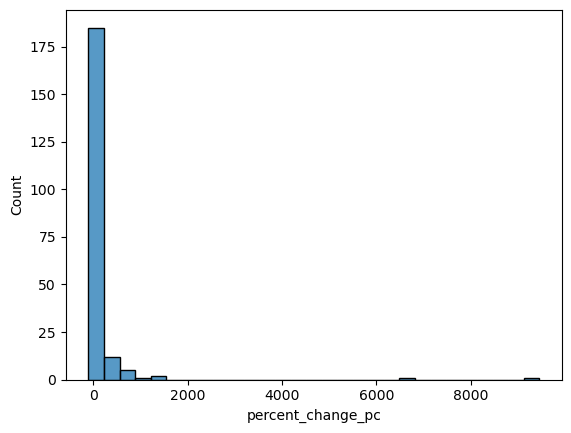

In [123]:
sns.histplot(data=msa_funded, x='percent_change_pc')

<Axes: xlabel='percent_change_pc', ylabel='Count'>

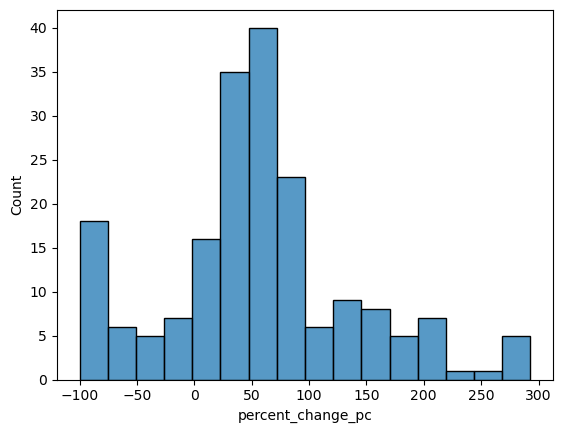

In [128]:
sns.histplot(data=msa_funded_percent_pc[:-15], x='percent_change_pc')

<Axes: xlabel='diff_log_funding', ylabel='Count'>

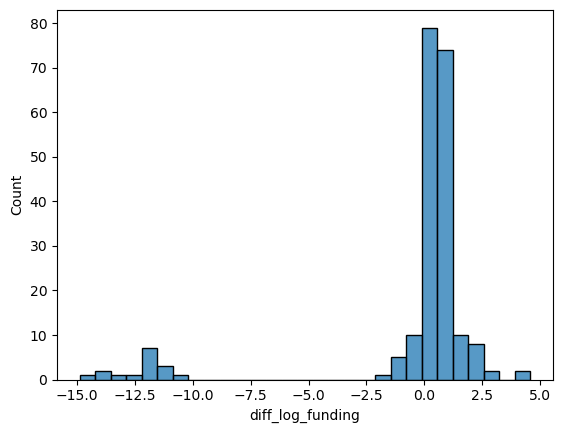

In [115]:
sns.histplot(data=msa_funded, x='diff_log_funding')

<Axes: xlabel='diff_log_funding_pc', ylabel='Count'>

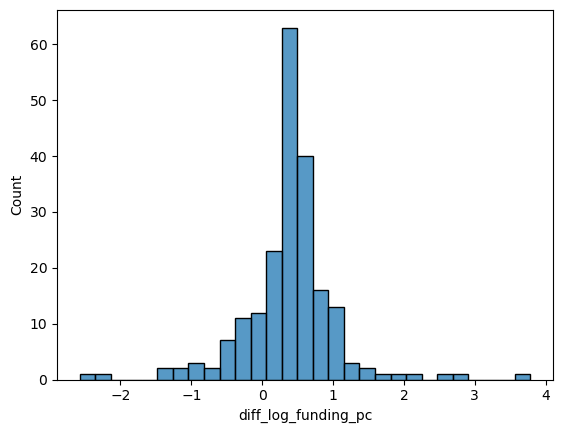

In [116]:
sns.histplot(data=msa_funded, x='diff_log_funding_pc')

### Split dataset

In [130]:
msa_funded_percent_pc.describe()

,funding_1998,funding_2003,log_funding_1998,log_funding_2003,funding_pc_1998,funding_pc_2003,log_funding_pc_1998,log_funding_pc_2003,diff_funding,diff_log_funding,diff_funding_pc,diff_log_funding_pc,percent_change,percent_change_pc
count,2.070000e+02,2.070000e+02,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,2.070000e+02,207.000000,207.000000,207.000000,207.000000,207.000000
mean,5.293990e+07,9.245386e+07,15.303999,14.955362,51.949950,84.906200,2.647155,3.024449,3.951396e+07,-0.348637,32.956250,0.377294,193.034824,173.506778
std,1.407525e+08,2.392394e+08,2.541490,4.918357,117.203816,179.045701,1.653295,1.853966,1.018802e+08,3.528419,65.162087,0.670617,856.561899,820.055044
min,2.343293e+04,0.000000e+00,10.061940,0.000000,0.092533,0.000000,0.088498,0.000000,-2.964121e+06,-14.902091,-12.150983,-2.576497,-100.000000,-100.000000
25%,5.972060e+05,8.546478e+05,13.299770,13.657924,2.299581,3.200112,1.193662,1.435085,3.315287e+05,0.292526,0.764588,0.196979,33.993967,23.893357
50%,3.383255e+06,8.089302e+06,15.034349,15.906054,11.092991,22.392408,2.492626,3.152411,3.342678e+06,0.527437,9.399710,0.420266,69.458446,59.385230
75%,3.363888e+07,5.633678e+07,17.331158,17.846839,50.491608,79.859275,3.941396,4.392710,2.960314e+07,0.820812,33.748728,0.621591,127.235023,115.752819
max,1.166826e+09,1.951413e+09,20.877552,21.391819,861.062300,1366.992200,6.759327,7.221099,7.845873e+08,4.590083,505.929900,3.784662,9750.401175,9452.003428


In [148]:
msa_above_median1998 = msa_funded[msa_funded['funding_pc_1998'] > msa_funded['funding_pc_1998'].median()]
msa_above_median1998 = msa_above_median1998.sort_values(by='diff_log_funding_pc', ascending=False)
msa_above_median1998.to_csv(base_path / "Data/NIH_v4/Working/categorized/above_median1998.csv")

In [149]:
msa_below_median1998 = msa_funded[msa_funded['funding_pc_1998'] < msa_funded['funding_pc_1998'].median()]
smallfund_smallgrowth =  msa_below_median1998[msa_below_median1998['diff_log_funding_pc'] < msa_below_median1998['diff_log_funding_pc'].median()]
smallfund_largegrowth =  msa_below_median1998[msa_below_median1998['diff_log_funding_pc'] > msa_below_median1998['diff_log_funding_pc'].median()]

smallfund_smallgrowth = smallfund_smallgrowth.sort_values(by='diff_log_funding_pc', ascending=False)
smallfund_smallgrowth.to_csv(base_path / "Data/NIH_v4/Working/categorized/smallfund_smallgrowth.csv")

smallfund_largegrowth = smallfund_largegrowth.sort_values(by='diff_log_funding_pc', ascending=False)
smallfund_largegrowth.to_csv(base_path / "Data/NIH_v4/Working/categorized/smallfund_largegrowth.csv")

<Axes: xlabel='funding_pc_1998', ylabel='diff_log_funding_pc'>

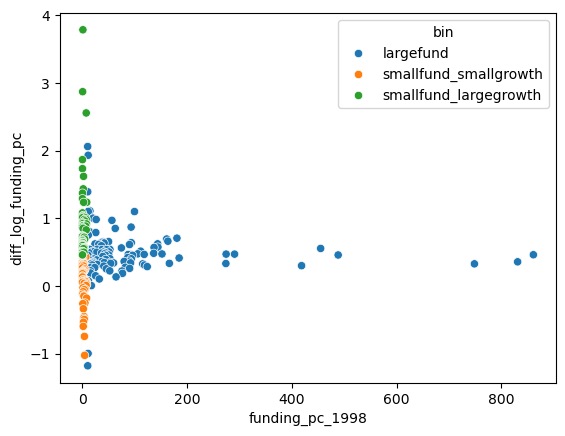

In [154]:
msa_above_median1998['bin'] = "largefund"
smallfund_smallgrowth['bin'] = "smallfund_smallgrowth"
smallfund_largegrowth['bin'] = "smallfund_largegrowth"

categorized = pd.concat([msa_above_median1998, smallfund_smallgrowth, smallfund_largegrowth], axis=0)
    
sns.scatterplot(
    data=categorized,
    x='funding_pc_1998',
    y='diff_log_funding_pc',
    hue='bin'
)
# This scatterplot makes sense but I don't think it's very useful